QN 1
1.1. Load the diabetes data into Python. Produce a correlation matrix of the explanatory 
variables. Make a heat-map of the matrix (using imagesc and colorbar) and describe the 
relationships between the variables. 

Feature DataFrame (X):
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  

Target variable (y):
0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64

Summary statistics for features:
                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.2

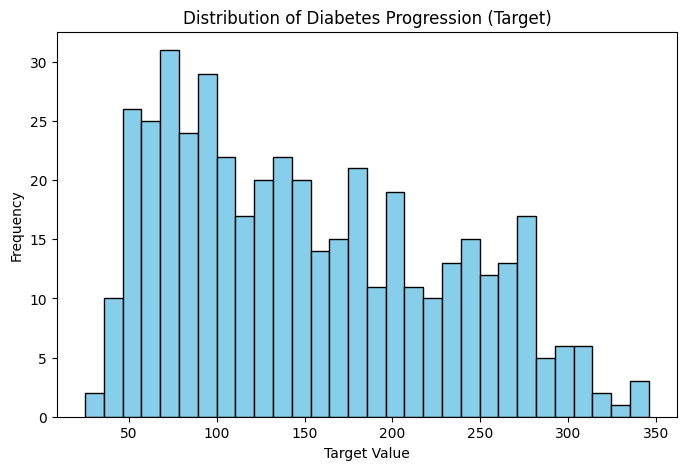

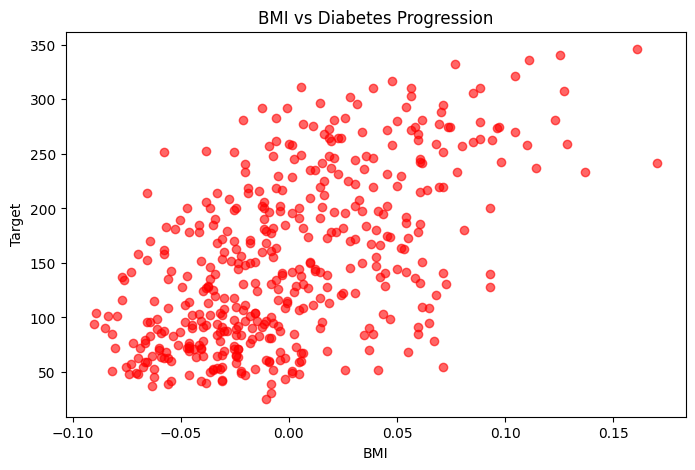

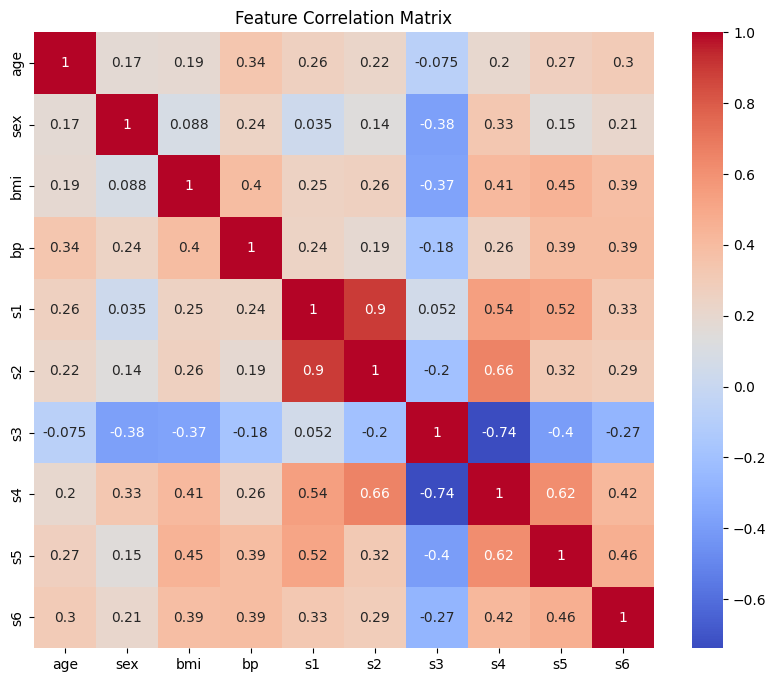

In [ ]:
# Import necessary libraries for data handling, visualization, and modeling
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error

         # Load dataset and prepare feature and target data

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name='target')

         # Display first few rows and summary statistics

print("Feature DataFrame (X):")
print(X.head())
print("\nTarget variable (y):")
print(y.head())
print("\nSummary statistics for features:")
print(X.describe())
print("\nSummary statistics for target:")
print(y.describe())

# Visualize the distribution of the target variable
plt.figure(figsize=(8,5))
plt.hist(y, bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Diabetes Progression (Target)")
plt.xlabel("Target Value")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# Visualize relationship between BMI and target variable
# -------------------------------
plt.figure(figsize=(8,5))
plt.scatter(X['bmi'], y, color='red', alpha=0.6)
plt.title("BMI vs Diabetes Progression")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.show()


### Visualize correlation between features using a heatmap

plt.figure(figsize=(10,8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()


1.3. Create a multivariate linear model using all ten variables and a constant. What are the 
Mean Squared Error and the adjusted R2 for your model? Are all variables significant? Could 
this be a problem of collinearity? 

In [ ]:
corr_matrix = X.corr()
print(corr_matrix)


          age       sex       bmi        bp        s1        s2        s3  \
age  1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
sex  0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
bmi  0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
bp   0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
s1   0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
s2   0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
s3  -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
s4   0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
s5   0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
s6   0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   

           s4        s5        s6  
age  0.203841  0.270774  0.301731  
sex  0.332115  0.149916  0.208133  
bmi  0.413807  0.446157  0.388680  
bp   0.2

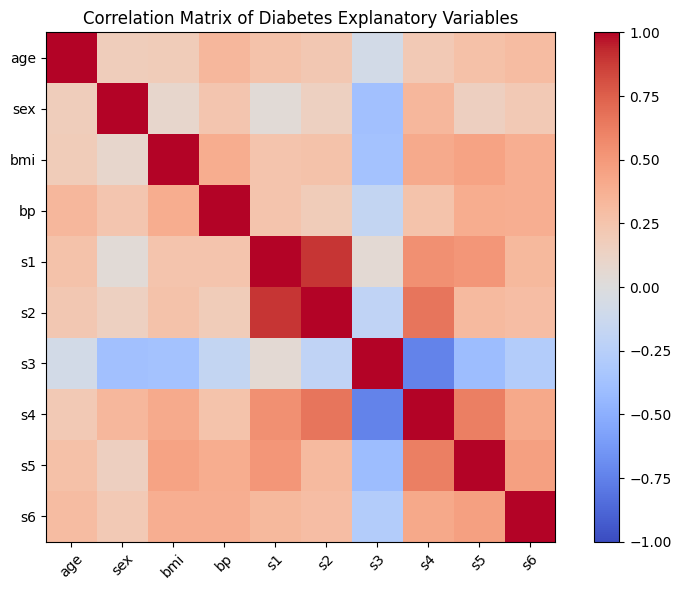

In [55]:
# Visualize the correlation between all features using a heatmap
plt.figure(figsize=(8, 6)) 
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)  
plt.colorbar(im) 
plt.xticks(range(len(feature_names)), feature_names, rotation=45) 
plt.yticks(range(len(feature_names)), feature_names) 
plt.title("Correlation Matrix of Diabetes Explanatory Variables")  
plt.tight_layout()

# Display the plot  
plt.show()  


1.5. How does the approach stepwise work in the sense of selecting variables? Use the 
stepwise function to interactively compose a model using forward selection. Which variables 
are selected? How does this function work? What is the MSE and R2 value for this new 
model?

In [42]:

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Sat, 10 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        12:13:58   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.0

 Which variables 
are selected? How does this function work? What is the MSE and R2 value for this new 
model?

In [ ]:
import pandas as pd
import statsmodels.api as sm
from sklearn.datasets import load_diabetes

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

def forward_selection(X, y, significance_level=0.05):  
    initial_features = []
    remaining_features = list(X.columns)
    selected_features = []
    
    while remaining_features:
        p_values = pd.Series(index=remaining_features, dtype=float)
        for feature in remaining_features:
            model = sm.OLS(y, sm.add_constant(X[initial_features + [feature]])).fit()
            p_values[feature] = model.pvalues[feature]
        min_p_value = p_values.min()
        if min_p_value < significance_level:
            best_feature = p_values.idxmin()
            initial_features.append(best_feature)
            selected_features.append(best_feature)
            remaining_features.remove(best_feature)
        else:
            break
            
    return selected_features

# Corrected call
selected_vars = forward_selection(X, y, significance_level=0.05)

print("Selected variables:", selected_vars)
X_selected = sm.add_constant(X[selected_vars])
model = sm.OLS(y, X_selected).fit()
print(model.summary())


Selected variables: ['bmi', 's5', 'bp', 's1', 'sex', 's2']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.515
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     76.95
Date:                Sat, 10 Jan 2026   Prob (F-statistic):           3.01e-65
Time:                        12:44:47   Log-Likelihood:                -2387.3
No. Observations:                 442   AIC:                             4789.
Df Residuals:                     435   BIC:                             4817.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

QUESTION 02

2.2:  Load in the titanic dataset and calculate the probability of survival for a passenger on the 
titanic. 


Load and clean the dataset

In [34]:


titanic = pd.read_excel("titanic3.xlsx")
titanic_data = titanic[['survived', 'pclass', 'sex', 'age']].copy()
titanic_data['sex'] = titanic_data['sex'].str.lower().map({'male': 1, 'female': 0})
titanic_data['age'] = pd.to_numeric(titanic_data['age'], errors='coerce')
titanic_data['survived'] = pd.to_numeric(titanic_data['survived'], errors='coerce')
titanic_data.dropna(inplace=True)
X = titanic_data[['pclass', 'sex', 'age']]
y = titanic_data['survived']
model = LogisticRegression(max_iter=1000)
model.fit(X, y)
titanic_data['survival_probability'] = model.predict_proba(X)[:, 1]
print(titanic_data.head())


   survived  pclass  sex    age  survival_probability
0         1       1    0  29.00              0.917192
1         1       1    1   0.92              0.713841
2         0       1    0   2.00              0.964602
3         0       1    1  30.00              0.486127
4         0       1    0  25.00              0.926775


2.3 Provide a table giving survival probabilities broken down by passenger class, gender and 
age. 

In [ ]:
# Load necessary libraries
import pandas as pd
from sklearn.linear_model import LogisticRegression
import numpy as np

# -------------------------------
# Load and preprocess Titanic data
# -------------------------------
titanic = pd.read_excel("titanic3.xlsx")
titanic_data = titanic[['survived', 'pclass', 'sex', 'age']].copy()

# Convert categorical and numeric data to proper formats
titanic_data['sex'] = titanic_data['sex'].str.lower().map({'male': 1, 'female': 0})
titanic_data['age'] = pd.to_numeric(titanic_data['age'], errors='coerce')
titanic_data['survived'] = pd.to_numeric(titanic_data['survived'], errors='coerce')

# Remove rows with missing values
titanic_data.dropna(inplace=True)

# -------------------------------
# Train logistic regression model to predict survival
# -------------------------------
X = titanic_data[['pclass', 'sex', 'age']]  # Features
y = titanic_data['survived']  # Target variable
model = LogisticRegression(max_iter=1000)
model.fit(X, y)

# Predict survival probabilities for each passenger
titanic_data['survival_probability'] = model.predict_proba(X)[:, 1]

# -------------------------------
# Group passengers by age and gender for summary
# -------------------------------
# Define age groups
bins = [0, 18, 60, 120]
labels = ['Child', 'Adult', 'Senior']
titanic_data['age_group'] = pd.cut(titanic_data['age'], bins=bins, labels=labels, right=False)

# Map gender back to text for readability
titanic_data['gender'] = titanic_data['sex'].map({1: 'Male', 0: 'Female'})

# Calculate average survival probability by class, gender, and age group
survival_table = (
    titanic_data.groupby(['pclass', 'gender', 'age_group'])['survival_probability']
    .mean()
    .reset_index()
)

# Convert probabilities to percentage and round for easier reading
survival_table['survival_probability'] = (survival_table['survival_probability'] * 100).round(2)

# Display the survival table
print(survival_table)


    pclass  gender age_group  survival_probability
0        1  Female     Child                 94.74
1        1  Female     Adult                 89.02
2        1  Female    Senior                 77.66
3        1    Male     Child                 64.81
4        1    Male     Adult                 41.04
5        1    Male    Senior                 22.78
6        2  Female     Child                 87.80
7        2  Female     Adult                 76.75
8        2  Female    Senior                 56.49
9        2    Male     Child                 40.89
10       2    Male     Adult                 23.18
11       2    Male    Senior                  9.32
12       3  Female     Child                 70.33
13       3  Female     Adult                 55.50
14       3  Female    Senior                 27.91
15       3    Male     Child                 16.92
16       3    Male     Adult                  9.96
17       3    Male    Senior                  3.02


C:\Users\Hp\AppData\Local\Temp\ipykernel_10380\2026662699.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_table = titanic_data.groupby(['pclass', 'gender', 'age_group'])['survival_probability'].mean().reset_index()


2.4 Build a logistic regression model for survival rates based on passenger class, sex and age. 
What are the parameter estimates and are these parameters statistically significant?

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
titanic = pd.read_excel("titanic3.xlsx")
titanic_data = titanic[['survived', 'pclass', 'sex', 'age']].copy()
titanic_data['sex'] = titanic_data['sex'].str.lower().map({'male': 1, 'female': 0})
titanic_data['age'] = pd.to_numeric(titanic_data['age'], errors='coerce')
titanic_data['survived'] = pd.to_numeric(titanic_data['survived'], errors='coerce')
titanic_data.dropna(inplace=True)
X = titanic_data[['pclass', 'sex', 'age']]
y = titanic_data['survived']
model = LogisticRegression(max_iter=1000)
model.fit(X, y)
y_pred = model.predict(X)
cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred) * 100  
print("Confusion Matrix:")
print(cm)
print(f"\nClassification Accuracy: {accuracy:.2f}%")


Confusion Matrix:
[[524  95]
 [127 300]]

Classification Accuracy: 78.78%


3. PCA (35 points)

3.3 Use   Python   yfinance   to   download   the   30   Dow   Jones   constituent   stocks 
( 'UNH','GS','HD','AMGN','MCD','MSFT','CAT','HON','V','TRV','CVX','JNJ','BA','AXP','WMT','IBM 
','PG','AAPL','CRM','JPM','MMM','NKE','MRK','DIS','KO','DOW','CSCO','WBA','VZ','INTC'). 

[*********************100%***********************]  28 of 28 completed


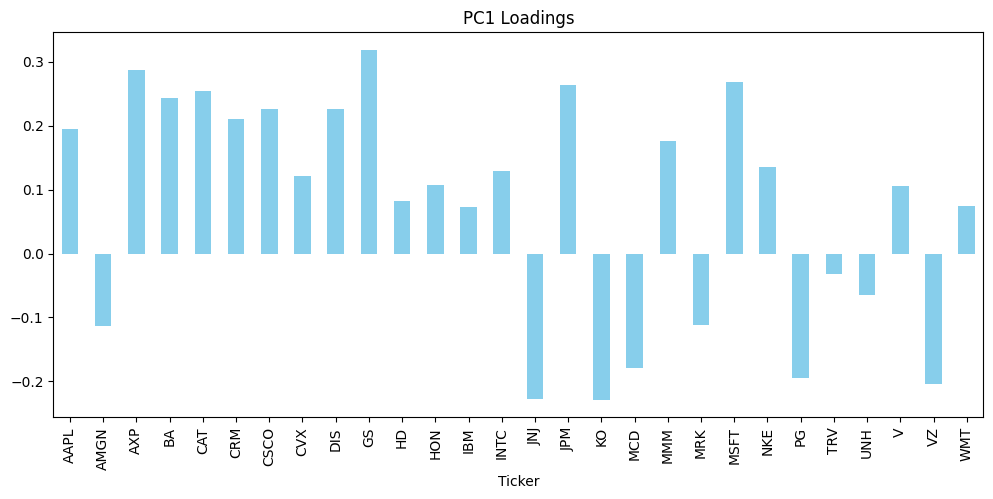

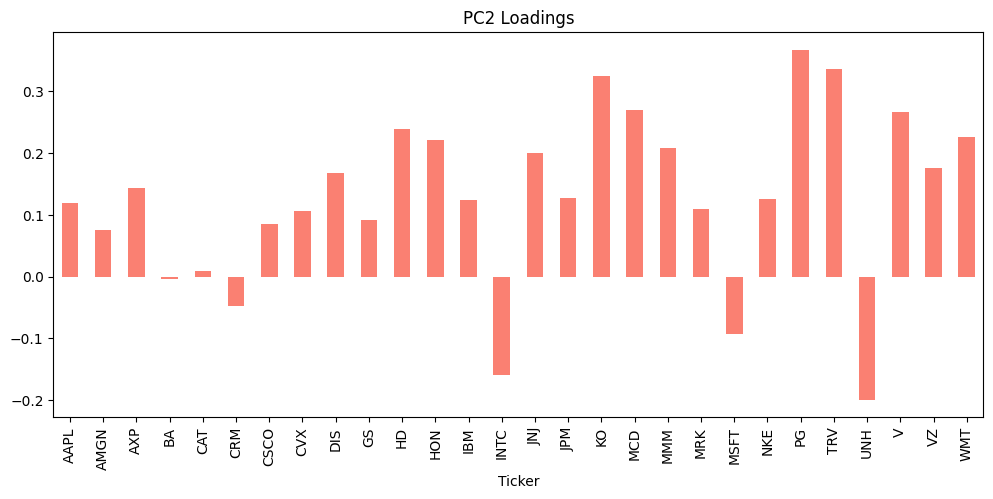

Tickers zilizopatikana: ['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT']
PC1 loadings mean: 0.07640005087355288


In [49]:
import yfinance as yf
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


tickers = ['UNH','GS','HD','AMGN','MCD','MSFT','CAT','HON','V','TRV',
           'CVX','JNJ','BA','AXP','WMT','IBM','PG','AAPL','CRM','JPM',
           'MMM','NKE','MRK','DIS','KO','CSCO','VZ','INTC']


data = yf.download(tickers, period="1y")
if isinstance(data.columns, pd.MultiIndex):
    if 'Adj Close' in data.columns.levels[0]:
        prices = data['Adj Close']
    else:
        prices = data['Close']
else:
    if 'Adj Close' in data.columns:
        prices = data['Adj Close']
    else:
        prices = data['Close']

prices = prices.dropna(axis=1, thresh=50)  

if len(prices.columns) == 0:
    raise ValueError("Hakuna ticker yoyote yenye data ya kutosha kwa mwaka mmoja.")
prices.to_excel("Dow30_prices.xlsx")

returns = prices.pct_change().dropna()
corr_matrix = returns.corr()
corr_matrix = corr_matrix.dropna(axis=0, how='any').dropna(axis=1, how='any')

pca = PCA()
pca.fit(corr_matrix)

loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(corr_matrix))],
                        index=corr_matrix.columns)

plt.figure(figsize=(12,5))
loadings['PC1'].plot(kind='bar', color='skyblue', title='PC1 Loadings')
plt.show()

plt.figure(figsize=(12,5))
loadings['PC2'].plot(kind='bar', color='salmon', title='PC2 Loadings')
plt.show()

print("Tickers zilizopatikana:", returns.columns.tolist())
print("PC1 loadings mean:", loadings['PC1'].mean())


3.4 Calculate the amount of variance explained by each principal component and make a 
‘Scree’ plot. How many principal components are required to explain 95% of the variance? 

[*********************100%***********************]  28 of 28 completed


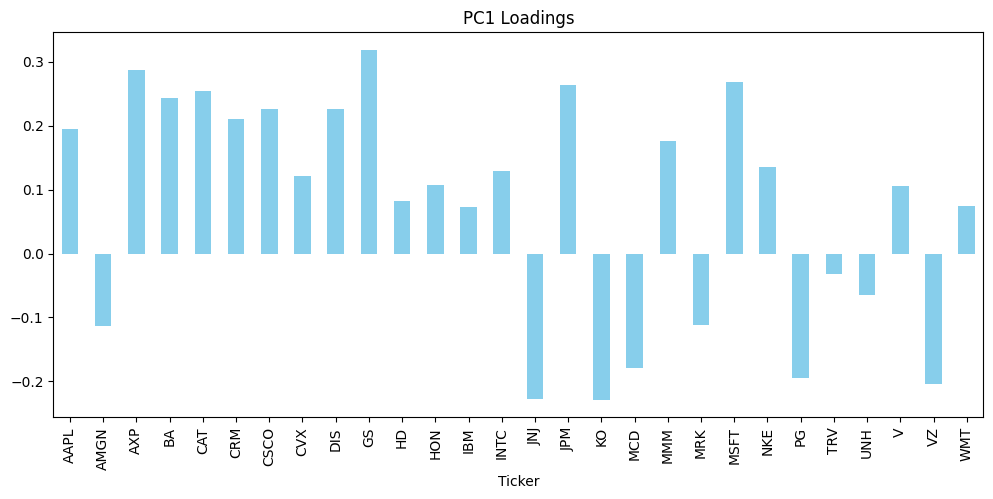

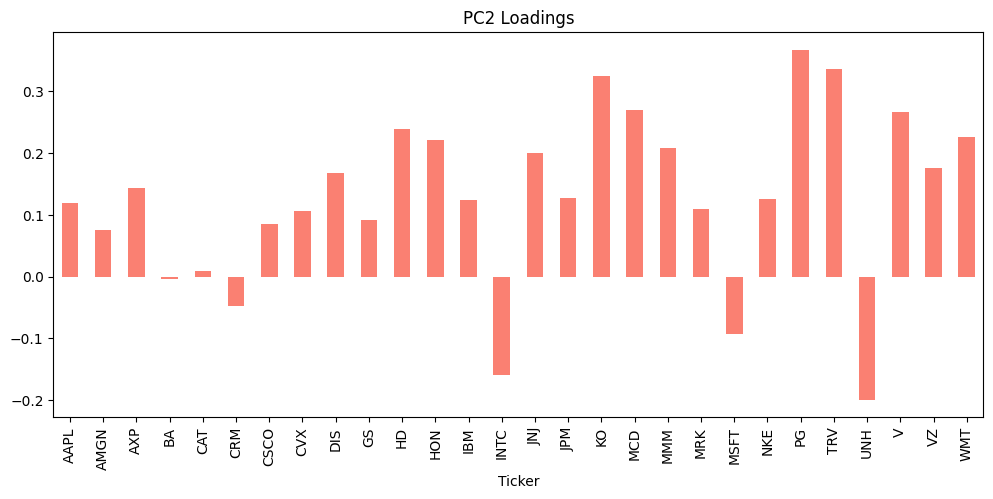

Tickers zilizopatikana: ['AAPL', 'AMGN', 'AXP', 'BA', 'CAT', 'CRM', 'CSCO', 'CVX', 'DIS', 'GS', 'HD', 'HON', 'IBM', 'INTC', 'JNJ', 'JPM', 'KO', 'MCD', 'MMM', 'MRK', 'MSFT', 'NKE', 'PG', 'TRV', 'UNH', 'V', 'VZ', 'WMT']
PC1 loadings mean: 0.07640008351997653


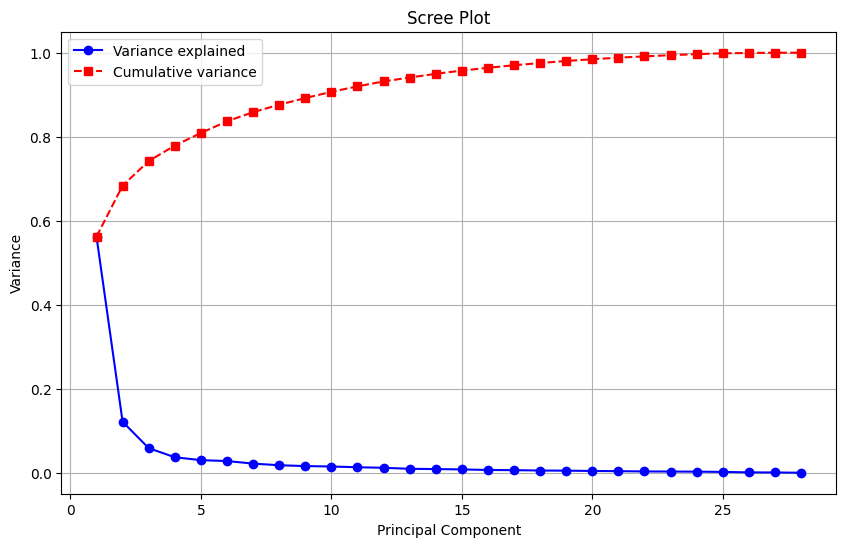

Number of principal components to explain 95% variance: 15


In [50]:
import yfinance as yf
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tickers = ['UNH','GS','HD','AMGN','MCD','MSFT','CAT','HON','V','TRV',
           'CVX','JNJ','BA','AXP','WMT','IBM','PG','AAPL','CRM','JPM',
           'MMM','NKE','MRK','DIS','KO','CSCO','VZ','INTC']  
data = yf.download(tickers, period="1y")
if isinstance(data.columns, pd.MultiIndex):
    if 'Adj Close' in data.columns.levels[0]:
        prices = data['Adj Close']
    else:
        prices = data['Close']
else:
    if 'Adj Close' in data.columns:
        prices = data['Adj Close']
    else:
        prices = data['Close']
prices = prices.dropna(axis=1, thresh=50) 

if len(prices.columns) == 0:
    raise ValueError("Hakuna ticker yoyote yenye data ya kutosha kwa mwaka mmoja.")
prices.to_excel("Dow30_prices.xlsx")
returns = prices.pct_change().dropna()
corr_matrix = returns.corr()
corr_matrix = corr_matrix.dropna(axis=0, how='any').dropna(axis=1, how='any')
pca = PCA()
pca.fit(corr_matrix)

loadings = pd.DataFrame(pca.components_.T,
                        columns=[f'PC{i+1}' for i in range(len(corr_matrix))],
                        index=corr_matrix.columns)
plt.figure(figsize=(12,5))
loadings['PC1'].plot(kind='bar', color='skyblue', title='PC1 Loadings')
plt.show()

plt.figure(figsize=(12,5))
loadings['PC2'].plot(kind='bar', color='salmon', title='PC2 Loadings')
plt.show()

print("Tickers zilizopatikana:", returns.columns.tolist())
print("PC1 loadings mean:", loadings['PC1'].mean())
explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance)+1), explained_variance, 'o-', color='blue', label='Variance explained')
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, 's--', color='red', label='Cumulative variance')
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.legend()
plt.show()

num_pc_95 = (cumulative_variance < 0.95).sum() + 1
print("Number of principal components to explain 95% variance:", num_pc_95)


3.5 Investigate the scatter plot of the first two principal components and calculate the average 
of all 30 stocks. Based on Euclidean distances away from this average, identify the three most 
distant stocks. Can you explain why these stocks are unusual?

C:\Users\Hp\AppData\Local\Temp\ipykernel_10380\571274777.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (loadings['PC1'][i], loadings['PC2'][i]), fontsize=9)


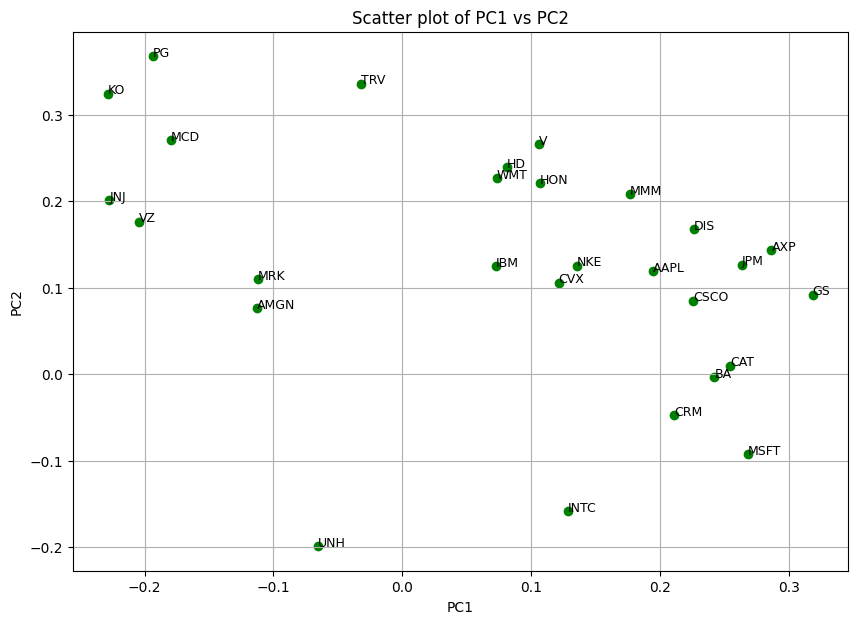

Centroid (average) of PC1 & PC2:
 PC1    0.076400
PC2    0.129323
dtype: float64
Three most distant stocks from centroid:
 Ticker
KO     0.361680
PG     0.360312
UNH    0.357525
dtype: float64


In [51]:
import numpy as np
plt.figure(figsize=(10,7))
plt.scatter(loadings['PC1'], loadings['PC2'], color='green')
for i, txt in enumerate(loadings.index):
    plt.annotate(txt, (loadings['PC1'][i], loadings['PC2'][i]), fontsize=9)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatter plot of PC1 vs PC2')
plt.grid(True)
plt.show()
centroid = loadings[['PC1','PC2']].mean()
print("Centroid (average) of PC1 & PC2:\n", centroid)
distances = np.sqrt((loadings['PC1'] - centroid['PC1'])**2 + 
                    (loadings['PC2'] - centroid['PC2'])**2)
most_distant = distances.sort_values(ascending=False).head(3)
print("Three most distant stocks from centroid:\n", most_distant)
